## Image Feature Extraction Techniques

In [1]:
# all necessary imports are listed below
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.cluster import KMeans
from skimage.feature import local_binary_pattern
import pywt

# libraries to generate a desc. - removed
from transformers import BlipProcessor, BlipForConditionalGeneration

# Libraries for neural style transfer 
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

print(torch.__version__)

2.5.1+cu121


To run on GPU use this in terminal: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

### Text Descriptors

Image Path: C:\Users\danie\Desktop\'\Daniela Curmi\University\Third Year\Final Year Project\Final Year Project Code Implementation\Website\paintings\Post_Impressionism\gregoire-boonzaier_waenhuiskrans.jpg
Genre: Post Impressionism 
Artist: Gregoire Boonzaier 
Painting Name: Waenhuiskrans 
Year: Unknown


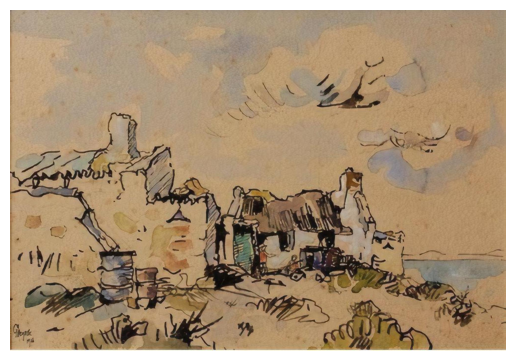

In [89]:
dataset_path = r'C:\Users\danie\Desktop\'\Daniela Curmi\University\Third Year\Final Year Project\Final Year Project Code Implementation\Website\paintings'

def text_features(dataset_path):
    # pick a random genre and image 
    genre = random.choice(os.listdir(dataset_path))
    rand_genre_path = os.path.join(dataset_path, genre)
    rand_img = random.choice(os.listdir(rand_genre_path))
    img_path = os.path.join(rand_genre_path, rand_img)

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # parse filename for genre, artist, painting, and year 
    filename = os.path.splitext(rand_img)[0]  
    parts = filename.split("_")                

    artist_part = parts[0]
    painting_part = "_".join(parts[1:])
    match = re.search(r"\b\d{4}\b", painting_part)
    if match:
        year = match.group(0)
        painting_part = painting_part.replace(year, "").replace("-", " ")
    else:
        year = "Unknown"
        painting_part = painting_part.replace("-", " ")

    # clean up outputs and display results
    genre = genre.replace("_", " ").title()
    artist = artist_part.replace("-", " ").title()
    painting = painting_part.replace("-", " ").title()

    print("Image Path:", img_path)
    print(f"Genre: {genre} \nArtist: {artist} \nPainting Name: {painting} \nYear: {year}")

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

    return img_path, image_rgb, genre, artist, genre, painting, year

img_path, image_rgb, genre, artist, genre, painting, year = text_features(dataset_path)

### Pixel-Based Feature Extraction Methods 

Used to to capture the spatial distribution of color in an image 

#### Colour Descriptors
- Colour Histograms
- Colour Moments Vector
- Colour Palette Extraction


C:\Users\danie\AppData\Local\Temp\ipykernel_5056\2341906548.py:60: RuntimeWarning: invalid value encountered in scalar power
  skew = np.mean((chan - mean) ** 3) ** (1./3)


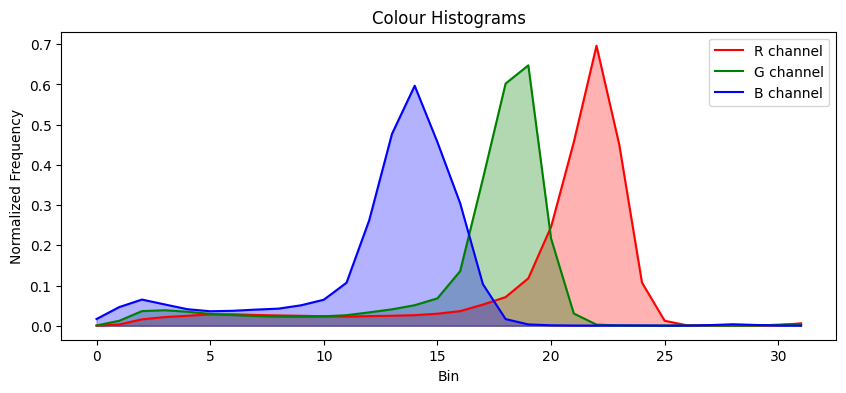

[6.196137e-05, 0.0031562748, 0.015863989, 0.021549415, 0.024770467, 0.0281023, 0.028491905, 0.026764497, 0.025584415, 0.024716016, 0.02353124, 0.022778315, 0.02385513, 0.024788305, 0.026299786, 0.029909506, 0.036364753, 0.05261647, 0.071169205, 0.11786086, 0.24581484, 0.45647788, 0.6961886, 0.4505559, 0.10733869, 0.01229276, 0.00083647855, 0.00058018375, 0.0006759422, 0.00026568284, 0.0013312307, 0.0059511084, 0.0006502296, 0.012324642, 0.036317393, 0.038510345, 0.034777377, 0.0295134, 0.026473891, 0.024044085, 0.022713006, 0.022314943, 0.023365038, 0.026198309, 0.03323916, 0.04077444, 0.051055633, 0.06808768, 0.13573408, 0.3650706, 0.60213965, 0.6473891, 0.21699926, 0.030382473, 0.0027288029, 0.0006502296, 0.00019182674, 0.00036293978, 0.0006682415, 0.0005142398, 8.825831e-05, 0.00034943086, 0.0026540535, 0.0041634506, 0.016634943, 0.046383623, 0.06505356, 0.05295579, 0.041090593, 0.036000554, 0.037119545, 0.040060345, 0.042462558, 0.050821852, 0.064677164, 0.10690205, 0.26248282, 0.4

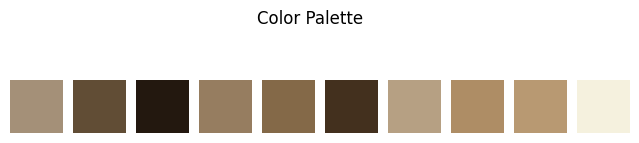

Palette type: Warm
Colour moments vector: [161.21092926  39.00323339          nan 135.38190084  35.3537883
          nan 104.19378355  31.36888766          nan]


In [91]:
# classify what type of colour palatte an image has (warm/cold/black and white etc...)
def classify_palette(palette):
    palette_norm = palette / 255.0
    warm_count, cool_count, gray_count = 0, 0, 0
    
    for color in palette_norm:
        r, g, b = color
        
        # if all channels are very close, check for greyscale/neutral
        if abs(r - g) < 0.1 and abs(r - b) < 0.1 and abs(g - b) < 0.1:
            gray_count += 1
            continue
        
        # convert to HSV for warm/cool tone check
        hsv = cv2.cvtColor(np.uint8([[color*255]]), cv2.COLOR_RGB2HSV)[0][0]
        h = hsv[0] 
        
        # hue in [0, 180] 
        if (0 <= h <= 20) or (160 <= h <= 180):  # reds
            warm_count += 1
        elif 20 < h <= 50:  # yellows/oranges
            warm_count += 1
        elif 50 < h <= 130:  # greens/blues
            cool_count += 1
        elif 130 < h < 160:  # purples/magentas
            cool_count += 1
    
    total = warm_count + cool_count + gray_count
    
    if gray_count == total:
        return "Black and White / Grayscale"
    elif warm_count > cool_count and warm_count >= total * 0.5:
        return "Warm"
    elif cool_count > warm_count and cool_count >= total * 0.5:
        return "Cool "
    else:
        return "Mixed / Balanced "
    
#    
def extract_colour_features(image_rgb, k=10, hist_size = 32):
    # compute and plot normalized histograms for R, G, B channels
    hist_range = (0, 256)
    colours = ['r', 'g', 'b']

    # calculate histogram per channel 
    hist_features = []
    hists = []
    for i, col in enumerate(colours):
        hist = cv2.calcHist([image_rgb], [i], None, [hist_size], hist_range)
        hist = cv2.normalize(hist, hist).flatten()
        hists.append(hist)
        hist_features.extend(hist)
    
    # compute colour moments for each channel
    chans = cv2.split(image_rgb)
    features = []
    for chan in chans:
        mean = np.mean(chan)
        std = np.std(chan)
        skew = np.mean((chan - mean) ** 3) ** (1./3)
        features.extend([mean, std, skew])
    moments =  np.array(features)

    # K-Means clustering to find the most popular colours - extract a colour palette
    pixels = image_rgb.reshape(-1, 3)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(pixels)
    colors = kmeans.cluster_centers_.astype(int)
    palette = colors

    classify_palette(palette)

    return moments, palette, hist, hists, hist_features, colours

moments, palette, hist, hists, hist_features, colours = extract_colour_features(image_rgb)

# Output results for colour histogram, colour moments vector, and pallette
plt.figure(figsize=(10, 4))
for hist, col in zip(hists, colours):
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
    plt.fill_between(range(len(hist)), hist, alpha=0.3, color=col)

plt.title("Colour Histograms")
plt.xlabel("Bin")
plt.ylabel("Normalized Frequency")
plt.legend()
plt.show()

print(hist_features)

plt.figure(figsize=(8, 2))
for i, color in enumerate(palette):
    plt.subplot(1, 10, i+1)
    plt.imshow([[color/255]])  
    plt.axis("off")
plt.suptitle("Color Palette")
plt.show()

palette_type = classify_palette(palette)
print("Palette type:", palette_type)
print("Colour moments vector:", moments)

**Colour Histograms**

Each curve represents distribution of pixel intensities for R, G, B (0-255 mapped into bins). Normalised frequency means the histogram was scaled so the values show proportions - not raw counts (it is unitless). 

Types of curve distributions and what they say about the painting: 
- Dominance: means the colour channel has high intensity across most of the range of bins, meaning that the painting contains a lot of tones that branch from this colour e.g. sea scapes will have a dominant blue channel.
- Presence: means that  the colour channel peaks around the middle bins which indicates that the colour is semi-dominant in the painting e.g. landscapes including trees, grass, etc...  
- Highlights/Shadows: significant rise in higher/lower bins, respectively. These are usually accents in a painting.
- Overlap: shows where colours are mixed e.g. purple, brown, grey, etc... Hence, a lot of overlap with blue and green; cool tones and overlap with red; warm tones. 

To describe the colour tone of a painting from these histogram plots, one can evaluate the above 3 curve types to indicate wether it is a warm/cool tone, balanced tones, and contrasts. 

**Colour Moments**

This a feature vector with a compact numerical representation of the color distribution of the painting - summary of the colour distribution. 

First three moments of a probability distribution for each colour channel: 
- Mean: average intensity of a the channel, thus overall brightness of the channel ranges from. Range: 0-255; 0-50 - dark tones i.e. shadows/deep tones, 51-150 - midtones i.e. balanced, not too dark/bright, 151-255 bright tones i.e. highlights/bright regions. 
- Standard Deviation: spread/contrast of a channel i.e. higher values indicate more variation in that colour e.g. many shades of red in a sunset painting. Range: 0-127; 0–20 - flat/ low variation, uniform channel with little contrast, 21–60 - moderate variation, noticable contrast, 61–127 - high variation with a wide spread of values and strong contrast.
- Skewness: asymmetric distribution i.e. +ve skew - more low values, darker tones and -ve skew - more high values, lighter tones. Range: −100 to +100 depending on implementation; approx. 0 - symmetric distribution, balanced light and dark, <0 - skewed toward light values, more high intensity pixels thus overall brighter channel, >0 - skewed toward dark values, more low intensity pixels thus overall darker channel.

These represent the 1st, 2nd and 3rd moments, respectively.
e.g. [R_mean, R_std, R_skew, G_mean, G_std, G_skew, B_mean, B_std, B_skew]

Used for image retrieval, classification, and comparison.

**Extracted Colour Palette**

Using K-Means clustering the top 10 most populated clusters from an image will be present in the colour pallette, indicating the most popular colours. 

#### Texture Descriptors

These capture structural, repetitive, or roughness patterns in an image - compact representation of the image’s surface structure.

- Local Binary Patterns
- Gabor filters
- Wavelets
- Fractal dimensions

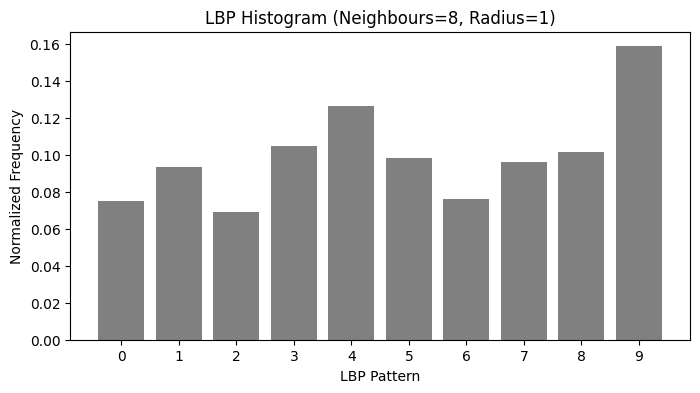

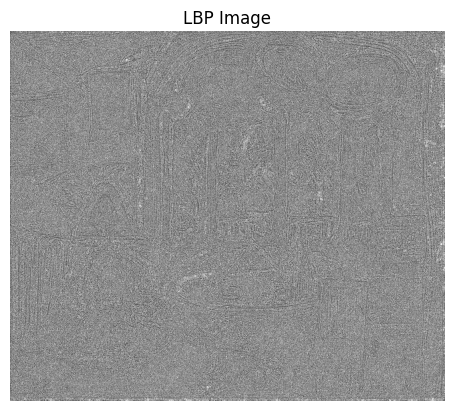

LBP feature vector: 
 [0.07510409 0.09359279 0.06904598 0.10477034 0.12654124 0.09817656
 0.07597373 0.09633441 0.10179762 0.15866325] 

Gabor Features (mean & variance per filter, length=32): 
 [1.798330e+02 5.699463e+03 7.755400e+01 3.432332e+03 4.549100e+01
 5.070360e+03 2.917300e+01 2.769176e+03 2.484890e+02 4.533290e+02
 3.326000e+00 3.878900e+01 1.761710e+02 8.833394e+03 4.945000e+00
 7.417000e+01 1.809010e+02 5.531027e+03 7.734500e+01 3.393900e+03
 5.168600e+01 5.941218e+03 3.010800e+01 2.647952e+03 2.485450e+02
 4.474710e+02 3.330000e+00 3.832700e+01 1.740240e+02 8.972710e+03
 4.968000e+00 7.509700e+01] 

Wavelet Features (mean & variance for LL, LH, HL, HH): 
 [ 1.64674537e+02  1.13701110e+04  2.18990251e-02  3.07053607e+02
 -9.60361919e-02  3.47838330e+02 -5.23778754e-03  7.66706599e+01] 

Fractal Dimension: 1.7269913415740488 



In [33]:
# every pixel compared with 8 neighbours in a 1 pixel radius 
def extract_lbp_features(image, neighbours=8, radius=1):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, neighbours, radius, method="uniform")
    
    # histogram of LBP
    hist, _ = np.histogram(lbp.ravel(),
                              bins=np.arange(0, neighbours + 3),
                              range=(0, neighbours + 2))
    hist = hist.astype("float")
    hist /= hist.sum()  
    
    plt.figure(figsize=(8,4))
    plt.bar(range(len(hist)), hist, tick_label=range(len(hist)), color="gray")
    plt.title(f"LBP Histogram (Neighbours={neighbours}, Radius={radius})")
    plt.xlabel("LBP Pattern")
    plt.ylabel("Normalized Frequency")
    plt.show()
    
    return hist, lbp

# plot the histogram, visualize the LBP image and print feature vector
hist, lbp_image = extract_lbp_features(image_rgb)
plt.imshow(lbp_image, cmap="gray")
plt.title("LBP Image")
plt.axis("off")
plt.show()
print ("LBP feature vector: \n", hist, "\n")

# produces a texture profile of the image across multiple orientations and scales
def extract_gabor_features(image, k=31):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    features = []
    
    # define gabor parameters i.e. orientations(theta), scales(sigma), wavelengths(lamda)
    for theta in (0, np.pi/4, np.pi/2, 3*np.pi/4):  
        for sigma in (1, 3):  
            for lamda in (np.pi/4, np.pi/2):  
                kernel = cv2.getGaborKernel((k, k), sigma, theta, lamda, 0.5, 0, ktype=cv2.CV_32F)
                fimg = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
                features.append(round(fimg.mean(), 3))
                features.append(round(fimg.var(), 3))
    return np.array(features)

gabor_features = extract_gabor_features(image_rgb)
print("Gabor Features (mean & variance per filter, length={}): \n".format(len(gabor_features)), gabor_features, "\n")

# decompose image into different frequency bands using discrete wavelet transform with haar wavlet
def extract_wavelet_features(image, wavelet="haar"):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coeffs2 = pywt.dwt2(gray, wavelet)
    LL, (LH, HL, HH) = coeffs2
    
    # mean and variance of each band
    features = [
        LL.mean(), LL.var(),
        LH.mean(), LH.var(),
        HL.mean(), HL.var(),
        HH.mean(), HH.var()
    ]
    return np.array(features)
wavelet_features = extract_wavelet_features(image_rgb, wavelet="haar")
print("Wavelet Features (mean & variance for LL, LH, HL, HH): \n", wavelet_features, "\n")

# value to describe the complexity of a fractal pattern 
def fractal_dimension(image, threshold=128):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # binarize
    _, bw = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    bw = bw // 255
    
    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
                               np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k*k))[0])

    # sizes of boxes
    p = min(bw.shape)
    n = 2**np.floor(np.log(p)/np.log(2))
    n = int(n)
    sizes = 2**np.arange(int(np.log(n)/np.log(2)), 1, -1)

    counts = []
    for size in sizes:
        counts.append(boxcount(bw, size))

    # fit log-log
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]  

fd = fractal_dimension(image_rgb)
print("Fractal Dimension:", fd, "\n")

**Local Binary Patterns**

The LBP Histogram/feature vector summarizes the painting texture distribution, where the x-axis represents LBP patterns for 8 neighbours i.e. 9 bins and y-axis is the normalised frequency of each pattern. If dominating patterns are 1-3 - little to no texture recognised (noisy/no structure), 4-6 - texture is mainly flat or smooth with slight edges, 7-9 good detail in texture features and well structured. Feature vector can be used for texture classification, retrieval, or similarity search. The LBP image is a map of textures at the pixel level, where each pixel is replaced with its LBP code instead of its intensity (0-255). The result is outlined since flat regions, edges and corners get different codes, darker areas - simple textures, brighter areas - complex textures like edges, corners, and details. (Just an output to visualise what LBP is seeing) LBP is rotation-invariant, robust to illumination changes thus only compares relative pixel intensities and provides efficient computation. 

**Gabor filters**

Gabor filters are designed to detect edges, frequencies, and orientations. Uses include texture analysis, face recognition, fingerprint matching and art/style analysis (brushstroke patterns, repetitive motifs). By combining different orientations, scales, and wavelengths, it can capture a multi-resolution texture description of the image. The large mean/variance values e.g. mean=123.086, var=3577.206 indicates orientations and scales where the texture response is strong and those patterns are dominant in the painting. The small values mean that those filters didn’t pick up much structure. Comparing these vectors between paintings tells you how similar their texture patterns are. This method produces a texture profile of the image across multiple orientations and scales. The histogram-like vector of means and variances can be used for clustering paintings by texture style, classification, or even similarity search. Sensitive to orientation and frequency but great for detecting repetitive patterns like brush strokes, fabric, or structural patterns in a painting.

Each filter produces two numbers (mean and var.); for a length 32 vector: 4 orientations × 2 sigmas × 2 lambdas = 16 filters 

**Wavelets**

Wavelet transforms decompose an image into different frequency bands; LL (Low-Low); coarse approximation, low-frequency, coarse version of the image i.e. general intensity and smooth structure, LH (Low-High); horizontal details, vertical edges and horizontal textures, HL (High-Low); vertical details, horizontal edges and vertical textures, HH (High-High); diagonal details, fine diagonal details and noise. Mean and variance per sub-band indicate the average coefficient value (indicates general direction or bias), and how much the coefficients vary (indicates amount of structure or texture energy), respectively.

Structure of the vector:
[LL_mean, LL_var, LH_mean, LH_var, HL_mean, HL_var, HH_mean, HH_var]

In general, its a multi-resolution analysis (due to diff. freq. bands) where features describe texture across scales i.e. low frequency = coarse structure, high frequency = fine details. (Table from chatGPT GPT-5 model)

| Feature     | Expected range             | What low values mean                    | What high values mean                                              |
| ----------- | -------------------------- | --------------------------------------- | ------------------------------------------------------------------ |
| **LL_mean** | ~0 to 255                  | Dark painting overall                   | Bright painting overall                                            |
| **LL_var**  | ~1,000 to 20,000           | Evenly lit / low-contrast (flat tones)  | High contrast / large light-dark areas                             |
| **LH_mean** | ~-5 to +5 (usually near 0) | Symmetry in vertical changes (balanced) | Biased vertical texture (e.g., many brushstrokes one direction)    |
| **LH_var**  | ~100 to 2,000              | Few vertical edges (smooth vertically)  | Strong vertical texture or repetitive vertical strokes             |
| **HL_mean** | ~-5 to +5                  | Balanced horizontally                   | Bias toward one horizontal direction (rare)                        |
| **HL_var**  | ~100 to 2,000              | Few horizontal edges                    | Strong horizontal strokes, horizons, or layering (landscapes)      |
| **HH_mean** | ~-2 to +2                  | Symmetric diagonal patterns             | Bias toward a diagonal structure (e.g., consistent lighting angle) |
| **HH_var**  | ~50 to 1,000               | Smooth with few details                 | Fine brush textures, intricate detail, strong diagonal patterns    |

**Fractal dimensions**

A single number describing the complexity of patterns. Higher = more detailed/chaotic texture, lower = smoother/simpler.Fractal dimension (FD) measures how complex or self-similar a texture is across scales.
It quantifies how much detail appears when zooming in.

FD close to 1 → smoother, line-like patterns, FD close to 2 → rough, highly textured or noise-like, and FD > 2 → rarely in images, would indicate very dense patterns. E.g. canvas strokes, cracks in paintings, or leaf surfaces often fall around 1.7–1.9.

#### Local feature detectors and descriptors
They find distinctive points in an image, like corners or edges of brushstrokes and describe their appearance in a way that’s invariant to scale, rotation, and sometimes illumination. They capture style-level and texture-level similarity.

- SIFT (Scale-Invariant Feature Transform) - uses gradient information
- FAST (Features from Accelerated Segment Test) - uses intensity differences
- ORB (Oriented FAST and Rotated BRIEF) - uses binary patterns or intensity comparisons

Using this paper in google doc. ORB best paintings

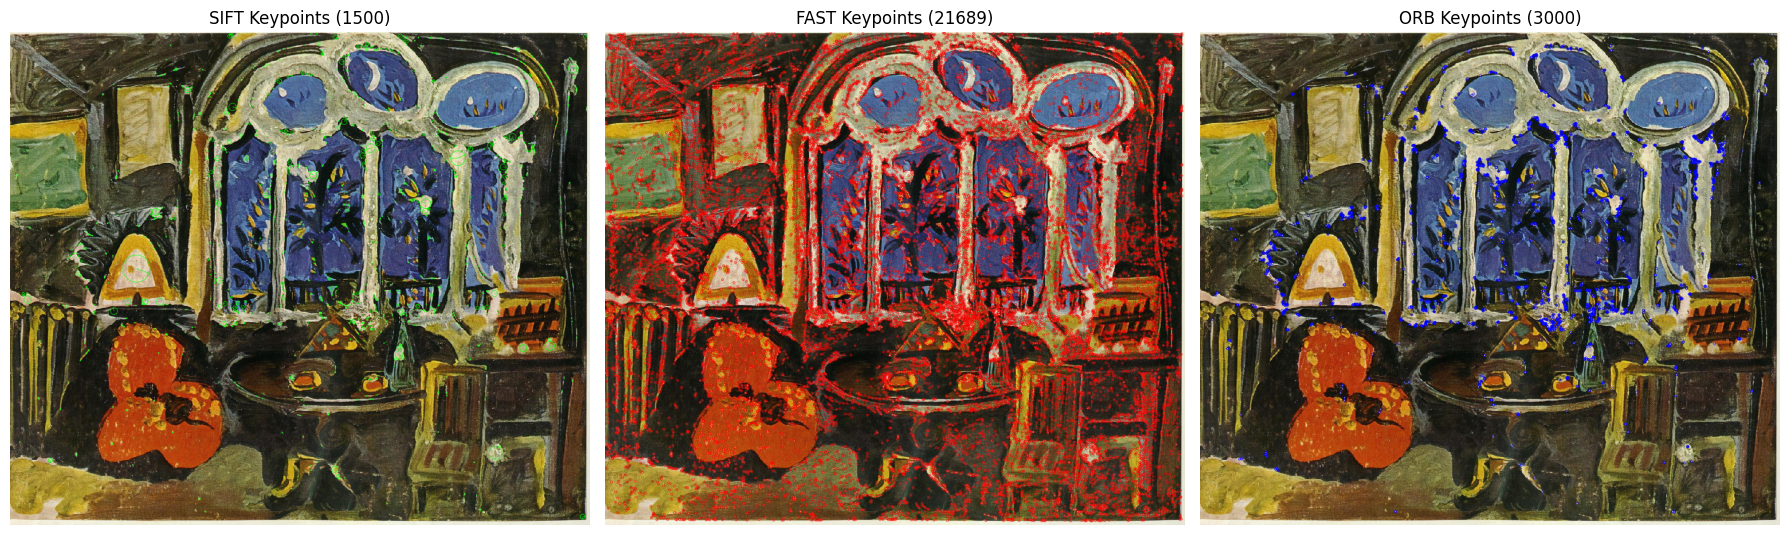

In [34]:
# feature detection methods
def detect_sift(gray):
    sift = cv2.SIFT_create(nfeatures=1500, contrastThreshold=0.04, edgeThreshold=10, sigma=1.6)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return keypoints, descriptors

def detect_fast(gray):
    fast = cv2.FastFeatureDetector_create(threshold=37, nonmaxSuppression=True)
    keypoints = fast.detect(gray, None)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.compute(gray, keypoints)
    return keypoints, descriptors
    
def detect_orb(gray):
    orb = cv2.ORB_create(nfeatures=3000) 
    keypoints, descriptors = orb.detectAndCompute(gray, None)
    return keypoints, descriptors

def visualize_keypoints(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect keypoints for each method
    kp_sift, _ = detect_sift(gray)
    kp_fast, _ = detect_fast(gray)
    kp_orb, _ = detect_orb(gray)

    # Draw keypoints on copies of the image
    img_sift = cv2.drawKeypoints(img, kp_sift, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img_fast = cv2.drawKeypoints(img, kp_fast, None, color=(255, 0, 0))
    img_orb  = cv2.drawKeypoints(img, kp_orb,  None, color=(0, 0, 255))

    # Display side-by-side
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img_sift)
    plt.title(f"SIFT Keypoints ({len(kp_sift)})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(img_fast)
    plt.title(f"FAST Keypoints ({len(kp_fast)})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_orb)
    plt.title(f"ORB Keypoints ({len(kp_orb)})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_keypoints(image_rgb)

SIFT: Computes gradient-based descriptors around keypoints, invariant to scale and rotation.
SURF: Detects corners by comparing pixel intensity patterns; you combine it with SIFT to describe them.
ORB: Combines FAST for detection and BRIEF (binary intensity comparisons) for description.

| Use Case                         | Why SIFT/SURF/ORB Help                                                                                                                                     |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Style similarity**             | Two paintings from the same artist or movement (e.g., Impressionism) will have similar texture and brushstroke patterns, which local features can capture. |
| **Brushstroke analysis**         | Keypoints often align along textured strokes, providing a “signature” for how an artist paints.                                                            |
| **Pattern or motif repetition**  | They can identify recurring patterns (e.g., similar sky texture, tree forms).                                                                              |
| **Visual matching / clustering** | You can compute feature vectors (mean of descriptors, or Bag of Visual Words representation) and compare them using cosine or Euclidean distance.          |


Parameters used from papers in google doc (most are default)

### Embeddings from Pre-trained CNNs 

CNN embeddings combine content and style features which can be used to compare the cosine similarity of two paintings

#### CNN deep features

In [35]:
# VGG19 for style and texture (Gram Matrix)

# ResNet50 for content and composition

# CLIP for semantic and conceptual 

### Gram Matrices for Style Features

The style represents the texture and pattern of a painting e.g. the type of brush stroke used or patterns in a painting


#### Brushstroke-level descriptors

#### Gram Matrix

In [36]:
# Preprocessing pipeline - normalise as VGG expects
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # Add batch dimension
    return image

painting = load_image(img_path)

def gram_matrix(features):
    # features: [batch, channels, height, width]
    b, c, h, w = features.size()
    features = features.view(c, h * w)  # flatten spatial dimensions
    gram = features @ features.t()      # standard matrix multiplication
    gram /= (c * h * w)                 # normalize
    return gram

vgg = models.vgg19(pretrained=True).features.eval()

# Specific layers that capture style 
style_layers = ['0', '5', '10', '19', '28']

def extract_gram_features(image, model, style_layers):
    grams = []
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in style_layers:
            grams.append(gram_matrix(x))
    return grams

with torch.no_grad():
    gram_features = extract_gram_features(painting, vgg, style_layers)

print(gram_features)

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[tensor([[ 0.0509, -0.0051,  0.0591,  ...,  0.0081, -0.0101, -0.0060],
        [-0.0051,  0.0544, -0.0153,  ..., -0.0092, -0.0068,  0.0061],
        [ 0.0591, -0.0153,  0.0780,  ...,  0.0005, -0.0110, -0.0071],
        ...,
        [ 0.0081, -0.0092,  0.0005,  ...,  0.0245, -0.0010, -0.0045],
        [-0.0101, -0.0068, -0.0110,  ..., -0.0010,  0.0078, -0.0009],
        [-0.0060,  0.0061, -0.0071,  ..., -0.0045, -0.0009,  0.0167]]), tensor([[ 0.3293,  0.0145,  0.0453,  ...,  0.0255,  0.1728,  0.1015],
        [ 0.0145,  0.2706, -0.0062,  ...,  0.1747,  0.0915,  0.0188],
        [ 0.0453, -0.0062,  0.0889,  ..., -0.0072, -0.0347,  0.0094],
        ...,
        [ 0.0255,  0.1747, -0.0072,  ...,  0.2953,  0.0958,  0.0074],
        [ 0.1728,  0.0915, -0.0347,  ...,  0.0958,  0.7048,  0.1864],
        [ 0.1015,  0.0188,  0.0094,  ...,  0.0074,  0.1864,  0.1754]]), tensor([[ 0.1811,  0.0232, -0.0102,  ...,  0.0075,  0.0260, -0.0221],
        [ 0.0232,  0.3525,  0.0518,  ...,  0.1088, -0.0595,

#### Modern stroke segmentation with Deep Learning

#### Composition and Semantic layout

#### Metric learning and feature fusion

### Vector Space Model

Term by Document Matrix (in this case Feature by Painting matrix)

Terms: feature dimensions (colour descriptors e.g. colour histogram, colour moment vector, colour palette, texture descriptors e.g. lbp, gabor filters, fractal dimenstions, wavelets, embeddings from cnns, gram matrix, etc...)

Document: painting (image)

Instead of TF-IDF, standardization + PCA are used where the value of that feature (after normalization, PCA, etc.) = term weight

Similarity: Use cosine/euclidian similarity to see which paintings are most similar to each other (to be used to for content-based)

It's used for information retreival (IR) to search for art with high

A painting is represented by one feature vector per feature type. E.g. Gram Matrix, colour histogram, wavelet feature, etc... Each of these is a feature vector, numerical representation of one visual characteristic. So, for painting P i:
v i(gram),v i(hist),v i(wavelet),v i(palette),v i(moment) 
are five separate feature vectors. Form the combined vector V i by concatinating/fusing each of the 5 five feature vectors with w j is the scaling/weighting coefficient to balance the influence of each feature type.

**Vector Space Model Recipe**

1. **Prepare Inventory and metadata**

Compute all the types of features (computed above) per image in the dataset and for each feature record the name, dimensionality, range, and how it was computed. Assign a stable canonical name and an ordering for each feature type. Example:

| Feature Type                    | Typical Size                                   | Example File / Key | Description                            |
| ------------------------------- | ---------------------------------------------- | ------------------ | -------------------------------------- |
| **Colour Moments Vector (CMV)** | 9 dims (3 channels × 3 stats: mean, std, skew) | `cmv_9d.npy`       | Simple color summary statistics        |
| **Wavelet Features**            | 32 dims                                        | `wavelet_32d.npy`  | Texture from multi-scale decomposition |
| **Colour Palette**              | 15 dims (5 colors × 3 channels)                | `palette_15d.npy`  | Dominant RGB colors                    |
| **Colour Histogram**            | 64 dims                                        | `hist_64d.npy`     | Global color distribution              |
| **Gram Matrix Features**        | 128 dims                                       | `gram_128d.npy`    | Style descriptor from CNN activations  |


Feature-Painting Matrix

| Feature ↓ / Painting →     | P₁    | P₂    | P₃    | P₄    | ... |
| -------------------------- | ----- | ----- | ----- | ----- | --- |
| CMV[0] (mean R)            | 0.12  | 0.10  | 0.15  | 0.11  | ... |
| CMV[1] (std G)             | 0.07  | 0.09  | 0.06  | 0.10  | ... |
| Wavelet[5]                 | -0.21 | -0.24 | -0.27 | -0.25 | ... |
| Palette[2] (dominant blue) | 0.45  | 0.12  | 0.60  | 0.10  | ... |
| Hist[14] (Hue bin)         | 0.08  | 0.01  | 0.09  | 0.03  | ... |
| Gram[87]                   | 0.10  | 0.22  | 0.16  | 0.19  | ... |
| ...                        | ...   | ...   | ...   | ...   | ... |


2. **Clean and Validate features**

Remove or Replace NaNs/Infinity/constant columns and ensure all feature vectors exist for each painting (so normalisation, PCA and similarity metrics won't work well). If some paintings have missing features impute/zero-fill/late-fusion. Look at distributions per feature type (plot them for fyp explanations). 

3. **Similarity metric and Normalisation strategy** 

Use Cosine Similarity or Euclidean; most commonly used cosine similarity since Euclidean is used for raw distances. For cosine use L2-normalisation per vector and for Euclidean use standardising per dimension. Perform cosine normalisation on the final combined feature vector (all feature vectors per feature type) per painting. Perform these steps at step 8.

4. **Preprocess each feature type separately**

Apply appropriate preprocessing based on the feature type e.g. for histograms use power-law normalisation and then L1/L2 normalise, for matrices flatten or use a specialised transformations (i.e. log diagonal, matrix) before normalisation, for raw numeric descriptors standardise (i.e. zero mean, unit variance) or scale to a consistent range, and for CNN embeddings center (i.e. subtract mean) and L2 normalise check re PCA/whitening. Imp. to treat diff feature types accordingly since it will bias the combined vector toward types with larger ranges. 

IF NEW PAINTINGS ARE ADDED AFTER DATASET: Save preprocessing parameters in pickled files e.g. scaler.pkl, pca.pkl, etc... to be loaded each time you need to compute features for a new image. The vector space model is only meaningful if every painting (old or new) is represented consistently in the same coordinate system, all feature vectors must lie in the same space to be compatible and meaningful. Pre-process it in exactly the same way as the training data.

5. **Dimensionality reduction and Decorrelation for each feature type**

Use PCA for high-dimensional descriptors like CNN layers, large histograms, etc... to reduce noise and dimension which will speed up nearest-neighbour search. Decide the target dimensions beforehand and find the balance between retained variance vs. storage/latency. Whitening components will make dimensions more istropic and avoid dominance of a few high-variance directions. Keep smaller, features (e.g. fractal dims, colour moments) as is if already low-dim.

6. **Weighting for each feature type** 

Start with uniform weights then plan to tune weights on a validation set using offline metrics to decide if certain features should be up/down weighted e.g. CNN embeddings/Gram matrix might be more powerful than raw texture descriptors. Save the weights to apply them consistently during concatenation. Imp. because raw concatenation without weighting gives disproportionate influence to features with higher dimensionality/variance (re previous step). 

7. **Fusion strategy**

Choose between early or late fusion. Early fusion will concatenate all the reduced feature vectors into one final vector per painting after pre-processing, PCA, and weighting steps. It's simple and has good performance for many tasks. Late fusion keeps seperate indices per feature and at query time, search each index and merge/score results like a weighted sum or learned combiner. This works for paintings with missing features and for implementing dynamic weighting so it's more felxible.

8. **Concatenate & finalize painting vectors**

Use the stable ordering of step 1, concatenate each painting's processed and weighted per-feature vector into one final vector per painting. After concatenation, L2-normalise each final vector (if cosine similarity was used in step 3). Store metadata that maps vector slices to the painting including feature positions (start/end indices) for each painting to be able to interpret the feature matrix. Meta data would include the following for each painting, stored in json or csv:
 {
  "P001": {
    "filename": "vangogh_starrynight.jpg",
    "artist": "Vincent van Gogh",
    "feature_indices": {
      "color_moments": [0, 9],
      "wavelets": [9, 29],
      "palette": [29, 44],
      "histogram": [44, 108],
      "gram_matrix": [108, 144]
    }
    "feature_weights": {
        "colour_moments": 0.3, 
        "wavelets": 0.2, 
        "palette": 0.3,
        "histogram": 0.4,
        "gram_matrix": 0.7
    }
  }
}

Final normalisation makes similarity computations consistent and enables cosine to reflect angular similarity across combined features. Hence, after normalisation perform cosine similarity.

9. **Build an efficient vector index** 

Choose an ANN (approx nearest neighbour) index; will probably use FAISS since dataset is relitively medium/large. ANN indexes enable fast top-k retrieval for real-time recommendations at scale. Decide on storage format, whether to use compression, and index update strategy (rebuild vs increment).

10. **Build user profiles**

The user profile is the query in the VSM, so the structure and type of profile determines personalsation quality. To create a user profile use both explicit and implicit data t. Explicit feedback includes user inputs such as name, age, gender, adding to favourites/not interested, add to gallary, survey/questionnaire (at the beginning before entering website). Implicit feedback includes time spent viewing the image, interaction history such as clicks, views, searches, analysing click streams, browsing duration, interaction with various item categories, social connections for collaborative filtering. The type of user profile is important for the filtering method to be used later on. Demographic profiles - based on age, gender, location etc... pros: useful for cold start when painting info is limited and cons: recommendations are less specific to the user's interest/lacks adaptivity, Content-based profiles - represent user interest by analysing features of paintings they've interacted with (user profile stored as a vector of keywords/terms) pros: effective for recommending niche items and provides high degree of transparency and cons: can lead to over-specialisation, recommending only items similar to what the user already likes, Collaborative profiles - uses users with similar tastes to recommend new things to the user instead of paintings similar to previously liked by the user - hence its based on the users interaction history (e.g., like/dislike) and is used to find "neighbors" with similar preferences pros: uncovers new unexpected interests for the user and requires no explicit metadata cons: cold-satrt problems and data sparsity as a large number of ratings are needed, Hybrid profiles - these profiles combine multiple approaches to leverage the strengths of each method and overcome individual weaknesses e.g. a system might use explicit ratings (collaborative) and item genres (content-based) to refine suggestions. Build a user vector with user's interaction history and normalise it to match the item vector normalisation. 

11. **Retreival and Scoring**

Retrieval includes finding candidate paintings based on similarity, where an input query vector is either a user/painting vector. Indexing e.g. FAISS is used to store painting vectors for fast retrieval and when query vector is fed into the index it's asking for top k most similar vectors based on cosine similarity and then the index returns candidate IDs of these paintings. Brute-force searches through all vectors and is computationally expensive (O(N) per query). On the other hand, ANN indexing reduces this to approximately O(log N) or even constant-time for large datasets and allows real-time recommendations, even when you have thousands of paintings.

Scoring ranks these fast approx. retrieved candidates and refines them into accurate rankings. After performing weighted cosine similarity return the top N which are the final recommendations. Feature fusion allows you to balance style, color, content, and composition aspects depending on your recommendation goal (e.g., stylistic similarity vs. thematic similarity).

weighted cosine similarity since feature fusion is being used: score(q,i)=j∑ ​wj ​cos(qj​,ij​) where wj is the weight of the feature type j.

12. **Re-ranking**

Re-ranking includes post retieval adjustments for continuous good recommendations. These include filtering already seen paintings, blending collaborative with content based, MMR (maximum marginal relevance) for diversity and relevance to control a lot of paintings having the same artist and same style, and bias correction for popular artists that dominate (apply penalty). All this is important because raw similarity ranking can lack diversity. 

13. **Explainability**

3 dots at the side of painting pop up will include why the painting was recommended, what features contributed and the top contributing features. Using slice mapping will allow per feature contributions to be computed and surface the top contributing features as an explanation for that recommendation. Instead of raw numerics include user friendly layout and explanations. 

| Type                           | Description                                                                            | Example message
| ------------------------------ | -------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------ |
| **Feature-based**              | Explain recommendations based on input features (color, texture, CNN embeddings, etc.) | “Recommended because it shares a similar color palette and texture with your selected painting.” |
| **Model-based**                | Use the model’s internal reasoning (attention, embeddings, gradients) to explain       | “High similarity in VGG19 feature space indicates shared brushstroke style.”                     |
| **User-based (Collaborative)** | Explain based on other users’ behaviors                                                | “Users who liked this painting also liked this one.” (Not applicable to your current system)     |
| **Post-hoc visual**            | Visualize which image regions contributed most                                         | Saliency or Grad-CAM visualization of regions driving similarity                                 |
| **Prototype-based**            | Show representative examples (clusters or style archetypes)                            | “This belongs to the same ‘Impressionist’ visual cluster as Monet’s works.”                      |


14. **Evaluation Metrics and Testing**

15. Edge Cases, Tuning, Re-ranking TO-DO





In [ ]:
# Vector Space Model Structure 

# Extract Features for all the paintings in the dataset
def feature_extractor(dataset_path):
    img_path, image_rgb, genre, artist, genre, painting, year = text_features(dataset_path)
    moments, palette, _, _, hist_features, _ = extract_colour_features(image_rgb)
    with torch.no_grad():
        gram_features = extract_gram_features(painting, vgg, style_layers)


## Collaborative Filtering

### User Profile 

#### Implicit and Explicit Feedback

### Neural Style Transfer

**Neural Transer Recipe**

Using a content image (e.g. cat photo) and a style image (e.g. Starry Night by Van Gogh) that the user will upload, this method will give the user a combination via neural style transfer.

Uses the pre-trained VGG19 CNN to extract multi-layer features. Content representation is extracted from deeper layers (structure and shapes) and style representation is extracted from shallower layers (texture and colour). Algorithm loop optimises pixels of the generated image to minimise the total loss (calculated using the loss function). 

If gpu is available use a larger image size and use loader to perform image transformations i.e. pre-processing for vgg19, used to load the image (also adds a batch dimension [1, 3, H, W]). Use the unloader to reverse normalization to convert tensors back to viewable images, used to save the final stylised image. 

The gram matrix measures feature correlations within a layer to capture style, hence encodes texture and colour. N.B. Two images have similar styles if their gram matrices are similar.

Perform feature extraction by running the vgg19 network which ectracts intermediate activations i.e. feature maps at specific layers. Content layer is conv4_2 to caapture structure and style layers conv1_1, conv2_1, conv3_1, conv4_1, conv5_1 to capture texture.

Total loss function is calculated using content and style loss i.e. measures how close generated features are to content features and how close generated Gram matrices are to style Gram matrices, respectively. The total variation loss is used for smoothness and to remove noise.

Optimisation loop:
1. Load content and style images
2. Load pretrained VGG19
3. Extract features and Gram matrices
4. Initialize generated image, optimise pixels of this tensor directly
5. Define optimizer
6. Training loop for n steps which teratively adjusts pixels of generated to minimize total loss
7. Save the final image

Parameters used in the style transfer like content_weight, style_weight, tv_weight can get more or less stylized outputs.

N.B. No epochs since no parameters are being trained and model is pretrained, since only generated image is being optimised. (Training the image not the model) Instead each optimisation step updates generated image tensor.

TO-DO: 
- try out more style focused approach apart from this version i.e. change parameter weights and optimiser


cuda
Step 0/300, total_loss: 127.4518, content: 0.0000, style: 127.2085, tv: 0.243365
Step 50/300, total_loss: 19.3353, content: 4.0277, style: 15.0361, tv: 0.271450
Step 100/300, total_loss: 10.3147, content: 3.5757, style: 6.4521, tv: 0.286887
Step 150/300, total_loss: 7.5266, content: 3.3597, style: 3.8713, tv: 0.295535
Step 200/300, total_loss: 6.2727, content: 3.2177, style: 2.7575, tv: 0.297526
Step 250/300, total_loss: 5.5928, content: 3.1145, style: 2.1833, tv: 0.294923
Step 300/300, total_loss: 5.1737, content: 3.0289, style: 1.8553, tv: 0.289524
Saved stylized image to generated_images/styled_post_imp.jpg


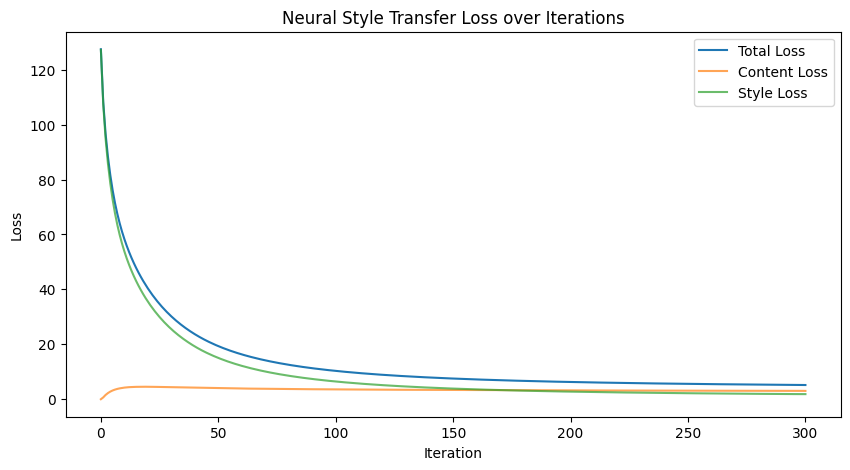

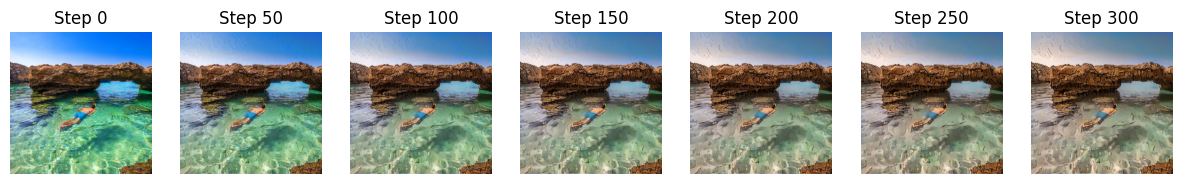

'generated_images/styled_post_imp.jpg'

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# --------------- Utilities ---------------
imsize = 512 if torch.cuda.is_available() else 256  

loader = transforms.Compose([
    transforms.Resize(imsize),
    transforms.CenterCrop(imsize),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
])

unloader = transforms.Compose([
    transforms.Normalize(mean=[0.,0.,0.],
                        std=[1/0.229,1/0.224,1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                        std=[1.,1.,1.]),
    transforms.Lambda(lambda t: torch.clamp(t, 0, 1)),
    transforms.ToPILImage()
])

def load_image(path, transform=loader, device=device):
    image = Image.open(path).convert('RGB')
    image = transform(image).unsqueeze(0)  # add batch dim
    return image.to(device, torch.float)

def tensor_to_pil(tensor):
    image = tensor.cpu().clone().squeeze(0)
    return unloader(image)

def save_image(tensor, path):
    image = tensor.cpu().clone().squeeze(0)
    pil = unloader(image)
    pil.save(path)

# --------------- Gram matrix ---------------
def gram_matrix(feature_maps):
    # feature_maps: tensor of shape [batch=1, C, H, W]
    b, c, h, w = feature_maps.size()
    features = feature_maps.view(c, h * w)  # [C, H*W]
    G = torch.mm(features, features.t())  # [C, C]
    return G.div(c * h * w)  # normalize

# --------------- Model to extract features ---------------
class VGGFeatures(nn.Module):
    def __init__(self, vgg, content_layers, style_layers):
        super().__init__()
        self.vgg_layers = vgg.features.eval()
        self.content_layers = content_layers
        self.style_layers = style_layers

    def forward(self, x):
        content_feats = {}
        style_feats = {}
        cur = x
        for name, layer in self.vgg_layers._modules.items():
            cur = layer(cur)
            
            # the caller will select layers by module index strings
            if name in self.content_layers:
                content_feats[name] = cur
            if name in self.style_layers:
                style_feats[name] = cur
        return content_feats, style_feats

# --------------- Loss functions (MSE) ---------------
mse_loss = nn.MSELoss()

def compute_content_loss(gen_feat, content_feat):
    return mse_loss(gen_feat, content_feat)

def compute_style_loss(gen_feat, style_gram):
    gen_gram = gram_matrix(gen_feat)
    return mse_loss(gen_gram, style_gram)

def total_variation_loss(img):
    # img [1,3,H,W]
    x_diff = img[:, :, :, 1:] - img[:, :, :, :-1]
    y_diff = img[:, :, 1:, :] - img[:, :, :-1, :]
    return torch.sum(torch.abs(x_diff)) + torch.sum(torch.abs(y_diff))

# --------------- Main style transfer function ---------------
def run_style_transfer(content_img_path, style_img_path,
                    output_path='output.jpg',
                    content_weight=1e0,
                    style_weight=1e6,
                    tv_weight=1e-6,
                    num_steps=500,
                    init_from_content=True,
                    snapshot_interval=50,
                    show_progress=False):
    # Load images
    content_img = load_image(content_img_path)
    style_img = load_image(style_img_path)

    # Load pretrained VGG19
    vgg = models.vgg19(pretrained=True).to(device).eval()

    # Choose layers by their module index in vgg.features
    style_layer_idxs = ['0', '5', '10', '19', '28']   # style layers
    content_layer_idxs = ['21']                       # content layer 
    feature_extractor = VGGFeatures(vgg, content_layer_idxs, style_layer_idxs)

    # Precompute style features' Gram matrices
    _, style_feats = feature_extractor(style_img)
    style_grams = {layer: gram_matrix(feat).detach() for layer, feat in style_feats.items()}

    # Precompute content features
    content_feats, _ = feature_extractor(content_img)
    content_targets = {layer: feat.detach() for layer, feat in content_feats.items()}

    # Initialize generated image
    if init_from_content:
        generated = content_img.clone().requires_grad_(True)
    else:
        generated = torch.randn_like(content_img).requires_grad_(True)

    # When using ADAM less style and more accurate content - do more testing
    optimizer = optim.Adam([generated], lr=0.02)
    # optimizer = optim.LBFGS([generated], max_iter=20, lr=1.0)
    # optimizer = optim.Adam([generated], lr=0.02)

    # Loss tracking
    losses = {"total": [], "content": [], "style": []}

    run = [0]
    snapshots = []
    while run[0] <= num_steps:
        def closure():
            optimizer.zero_grad()
            gen_content_feats, gen_style_feats = feature_extractor(generated)

            # content loss
            c_loss = 0.0
            for layer in content_targets:
                c_loss += compute_content_loss(gen_content_feats[layer], content_targets[layer])
            c_loss = c_loss * content_weight

            # style loss
            s_loss = 0.0
            for layer in style_grams:
                s_loss += compute_style_loss(gen_style_feats[layer], style_grams[layer])
            s_loss = s_loss * style_weight

            # total variation loss 
            tv = tv_weight * total_variation_loss(generated)

            loss = c_loss + s_loss + tv
            loss.backward()

            # Record losses
            losses["total"].append(loss.item())
            losses["content"].append(c_loss.item())
            losses["style"].append(s_loss.item())

            if show_progress and run[0] % 50 == 0:
                print(f"Step {run[0]}/{num_steps}, total_loss: {loss.item():.4f}, content: {c_loss.item():.4f}, style: {s_loss.item():.4f}, tv: {tv.item():.6f}")
                snapshots.append(tensor_to_pil(generated.clone().detach()))

            run[0] += 1
            return loss

        optimizer.step(closure)

    # Clamp output and save
    with torch.no_grad():
        final_img = generated.clone().detach()
        final_img = torch.clamp(final_img, -5, 5)  # keep in some numeric range
    save_image(final_img, output_path)
    print(f"Saved stylized image to {output_path}")

    # --------------- Plot losses ---------------
    plt.figure(figsize=(10,5))
    plt.plot(losses["total"], label='Total Loss')
    plt.plot(losses["content"], label='Content Loss', alpha=0.7)
    plt.plot(losses["style"], label='Style Loss', alpha=0.7)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Neural Style Transfer Loss over Iterations')
    plt.legend()
    plt.show()

    # --------------- Display intermediate snapshots ---------------
    if snapshots:
        fig, axes = plt.subplots(1, len(snapshots), figsize=(15, 5))
        for i, img in enumerate(snapshots):
            axes[i].imshow(img)
            axes[i].set_title(f"Step {i * snapshot_interval}")
            axes[i].axis("off")
        plt.show()


    return output_path

run_style_transfer(
    content_img_path="ref_photos/comino-swimming-snorkeling-malta.jpg",
    style_img_path=img_path, #img_path
    output_path="generated_images/styled_post_imp.jpg",
    num_steps=300,
    snapshot_interval=50,
    show_progress=True
)
